In [17]:
import os
import sys
p = os.path.abspath('../..')
if p not in sys.path:
    sys.path.append(p)
    
from waveorder.io.reader import MicromanagerReader
from waveorder.io.writer import WaveorderWriter
from recOrder.recOrder.io.config_reader import ConfigReader
from recOrder.recOrder.compute.QLIPP_compute import *
from recOrder.recOrder.io.utils import load_bg
import json
from waveorder.util import wavelet_softThreshold

In [2]:
class qlipp_3D_pipeline:

    def __init__(self, config, data: MicromanagerReader, sample: str):
        self.config = config
        self.data = data
        self.calib_meta = json.load(open(self.config.calibration_metadata))
        self.sample = sample

        #TODO: Parse positions if not 'all', parse timepoints if not 'all'
        self.pos = data.get_num_positions() if self.config.positions == 'all' else NotImplementedError
        self.t = data.frames if self.config.timepoints == 'all' else NotImplementedError

        self.channels = self.config.output_channels
        self.chan_names = self.data.channel_names
        self.bg_path = self.config.background
        self.bg_roi = self.config.background_ROI
        self.bg_correction = self.config.background_correction
        self.img_dim = (self.data.height, self.data.width, self.data.slices)
        
        self.reconstructor = initialize_reconstructor((self.img_dim[0], self.img_dim[1]), self.config.wavelength,
                                         self.calib_meta['Summary']['~ Swing (fraction)'],
                                         len(self.calib_meta['Summary']['ChNames']),
                                         self.config.NA_objective, self.config.NA_condenser,
                                         self.config.magnification, self.img_dim[2], self.config.z_step,
                                         self.config.pad_z, self.config.pixel_size,
                                         self.config.background_correction, self.config.n_objective_media,
                                         self.config.use_gpu, self.config.gpu_id)

        # self.bg_data = load_bg(self.bg_path, self.img_dim[0], self.img_dim[1], self.bg_roi)
        # self.reconstructor = initialize_reconstructor(self.img_dim, self.config.wavelength, self.config.swing)

        if self.data.channels < 4:
            raise ValueError(f'Number of Channels is {data.channels}, cannot be less than 4')

    def reconstruct(self):

        bg_data = load_bg(self.bg_path, self.img_dim[0], self.img_dim[1], self.bg_roi)

        #TODO: read step size from metadata


        #TODO: Add check to make sure that State0..4 are the first 4 channels
        bg_stokes = self.reconstructor.Stokes_recon(bg_data)
        bg_stokes = self.reconstructor.Stokes_transform(bg_stokes)

        data_shape = (self.t, len(self.channels), self.img_dim[2], self.img_dim[0], self.img_dim[1])
        chunk_size = (1, 1, 1, self.img_dim[0], self.img_dim[1])

        writer = WaveorderWriter(self.config.processed_dir, 'physical')
        writer.create_zarr_root(f'{self.sample}.zarr')
        writer.store.attrs.put(self.config.yaml_config)


        print(f'Beginning Reconstruction...')
        #TODO: write fluorescence data from remaining channels, need to get their c_idx
        for pos in range(self.pos):

            writer.create_position(pos)
            writer.init_array(data_shape, chunk_size, self.channels)

            if pos != 0:
                pos_tot_time = (pos_end_time-pos_start_time)/60
                total_time = pos_tot_time*self.pos
                remaining_time = total_time - pos*pos_tot_time
                print(f'Estimated Time Remaining: {np.round(remaining_time,0):0.0f} min')

            pos_start_time = time.time()
            for t in range(self.t):

                print(f'Reconstructing Position {pos}, Time {t}')
                time_start_time = time.time()
                position = self.data.get_array(pos)

                # Add pre-proc denoising
                if self.config.preproc_denoise_use:

                    stokes = reconstruct_QLIPP_stokes(position[t], self.reconstructor, bg_stokes)
                    self.stokes = self.preproc_denoise(stokes)
                    recon_data = self.bire_from_stokes(stokes)

                if not self.config.preproc_denoise_use:
                    recon_data = reconstruct_QLIPP_birefringence(position[t], self.reconstructor, bg_stokes)


                if 'Phase3D' in self.channels:
                    print('Computing Phase...')
                    phase3D = self.reconstructor.Phase_recon_3D(np.transpose(recon_data[2], (1, 2, 0)),
                                                           method=self.config.phase_denoiser_3D,
                                                           reg_re=self.config.Tik_reg_ph_3D, rho=self.config.rho_3D,
                                                           lambda_re=self.config.TV_reg_ph_3D, itr=self.config.itr_3D,
                                                           verbose=False)

                for chan in range(len(self.channels)):
                    if 'Retardance' in self.channels[chan]:
                        ret = recon_data[0] / (2 * np.pi) * self.config.wavelength
                        writer.write(ret, t=t, c=chan)

                    elif 'Orientation' in self.channels[chan]:
                        writer.write(recon_data[1], t=t, c=chan)
                    elif 'Brightfield' in self.channels[chan]:
                        writer.write(recon_data[2], t=t, c=chan)
                    elif 'Phase3D' in self.channels[chan]:
                        writer.write(np.transpose(phase3D, (2,0,1)), t=t, c=chan)
                    else:
                        #TODO: Add writing fluorescence
                        raise NotImplementedError(f'{self.channels[chan]} not available to write yet')
                time_end_time = time.time()
                print(f'Finished Reconstructing Position {pos}, Time {t} ({(time_end_time-time_start_time)/60:0.1f} min)')

            pos_end_time = time.time()

    def preproc_denoise(self, stokes):

        params = []

        for i in range(len(self.config.preproc_denoise_channels)):
            threshold = 0.1 if self.config.preproc_denoise_thresholds is None \
                else self.config.preproc_denoise_thresholds[i]
            level = 1 if self.config.preproc_denoise_levels is None \
                else self.config.preproc_denoise_levels[i]

            params.append([self.config.preproc_denoise_channels[i], threshold, level])

        for chan in range(len(params)):
            stokes_denoised = np.zeros_like(stokes)

            if 'S0' in params[chan][0]:
                for z in range(len(stokes)):
                    stokes_denoised[z, 0, :, :] = wavelet_softThreshold(stokes[z, 0, :, :], 'db8',
                                                                        params[chan][1], params[chan][2])
            elif 'S1' in params[chan][0]:
                for z in range(len(stokes)):
                    stokes_denoised[z, 1, :, :] = wavelet_softThreshold(stokes[z, 1, :, :], 'db8',
                                                                        params[chan][1], params[chan][2])
            if 'S2' in params[chan][0]:
                for z in range(len(stokes)):
                    stokes_denoised[z, 2, :, :] = wavelet_softThreshold(stokes[z, 2, :, :], 'db8',
                                                                        params[chan][1], params[chan][2])

            if 'S3' in params[chan][0]:
                for z in range(len(stokes)):
                    stokes_denoised[z, 3, :, :] = wavelet_softThreshold(stokes[z, 3, :, :], 'db8',
                                                                        params[chan][1], params[chan][2])

        return stokes_denoised

    def bire_from_stokes(self, stokes):

        recon_data = np.zeros([stokes.shape[0], 4, stokes.shape[-2], stokes.shape[-1]])
        for z in range(len(stokes)):

            recon_data[z, :, :, :] = self.reconstructor.Polarization_recon(stokes[z])

        return np.transpose(recon_data, (1,0,2,3))

In [3]:
cfg_path = '/home/camfoltz2/recOrder/recOrder/examples/config_QLIPP_3D.yml'
data_path = '/gpfs/CompMicro/rawdata/hummingbird/Cameron/2021_05_10_NewKazansky_63x_WI_04NA/NewKaz_2T_3P_65Z_2048_2048_1'

config = ConfigReader(cfg_path)
data = MicromanagerReader(data_path, 'ometiff', extract_data=True)

/home/camfoltz2/recOrder/recOrder/io/config_reader.py:112: YAMLLoadWarning: calling yaml.load() without Loader=... is deprecated, as the default Loader is unsafe. Please read https://msg.pyyaml.org/load for full details.
  object.__setattr__(self, 'yaml_config', yaml.load(f))


In [4]:
qlipp = qlipp_3D_pipeline(config, data, 'sample')

Initializing Reconstructor...
Finished Initializing Reconstructor (1.57 min)


In [ ]:
qlipp.reconstruct()

In [6]:
position = qlipp.data.get_array(0)
t=0

bg_data = load_bg(qlipp.bg_path, qlipp.img_dim[0], qlipp.img_dim[1], qlipp.bg_roi)

bg_stokes = qlipp.reconstructor.Stokes_recon(bg_data)
bg_stokes = qlipp.reconstructor.Stokes_transform(bg_stokes)

stokes = reconstruct_QLIPP_stokes(position[t], qlipp.reconstructor, bg_stokes)

In [7]:
np.shape(stokes)

(65, 5, 2048, 2048)

In [8]:
import matplotlib.pyplot as plt

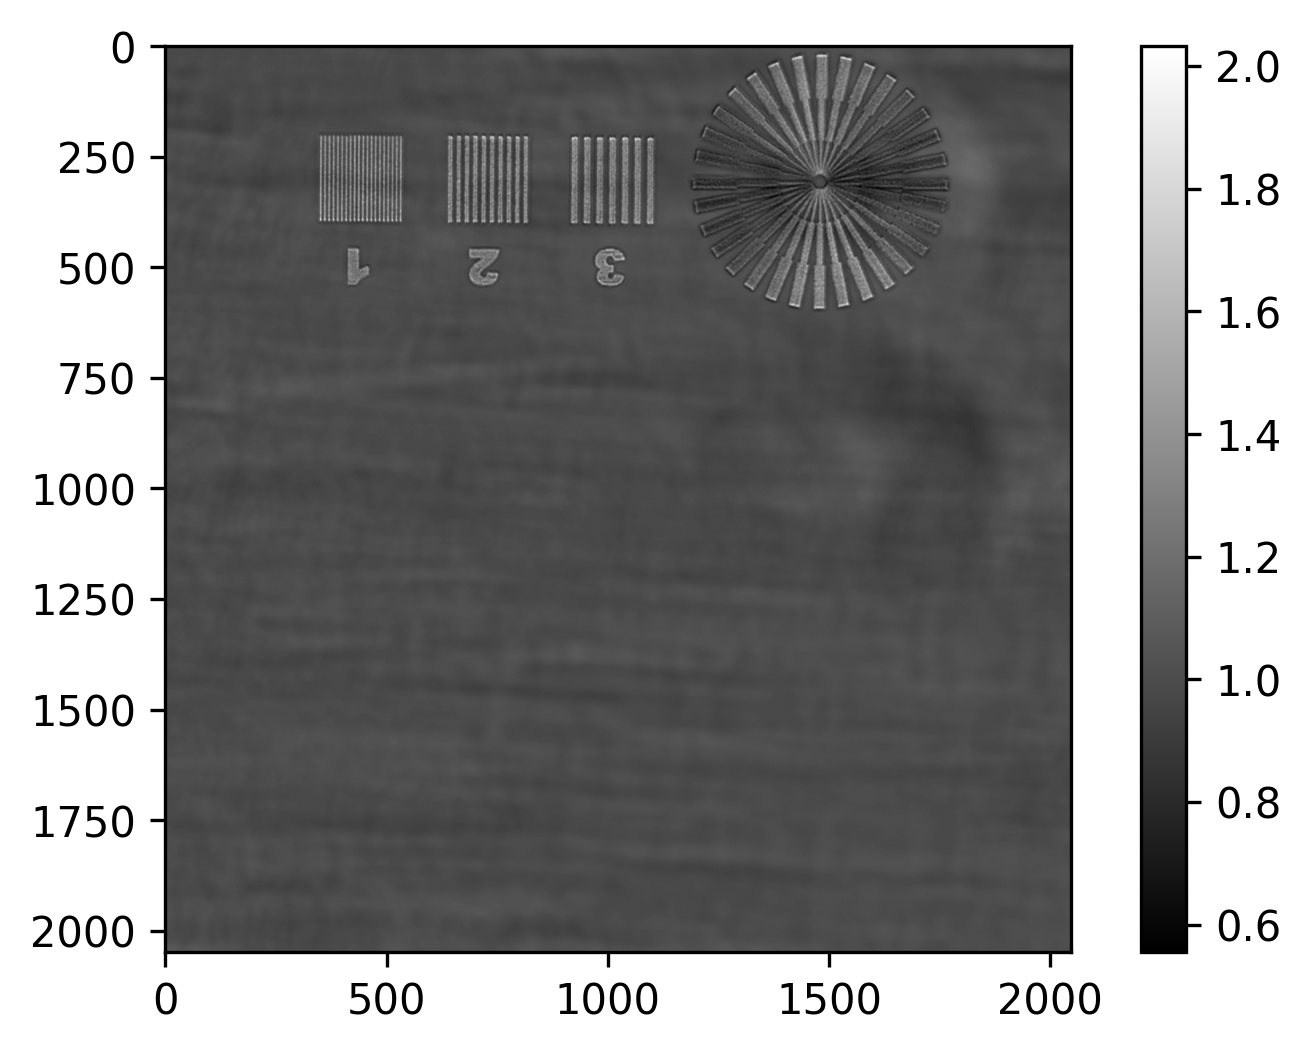

In [70]:
plt.figure(dpi=300)
plt.imshow(stokes[32,0], 'gray')
plt.colorbar()

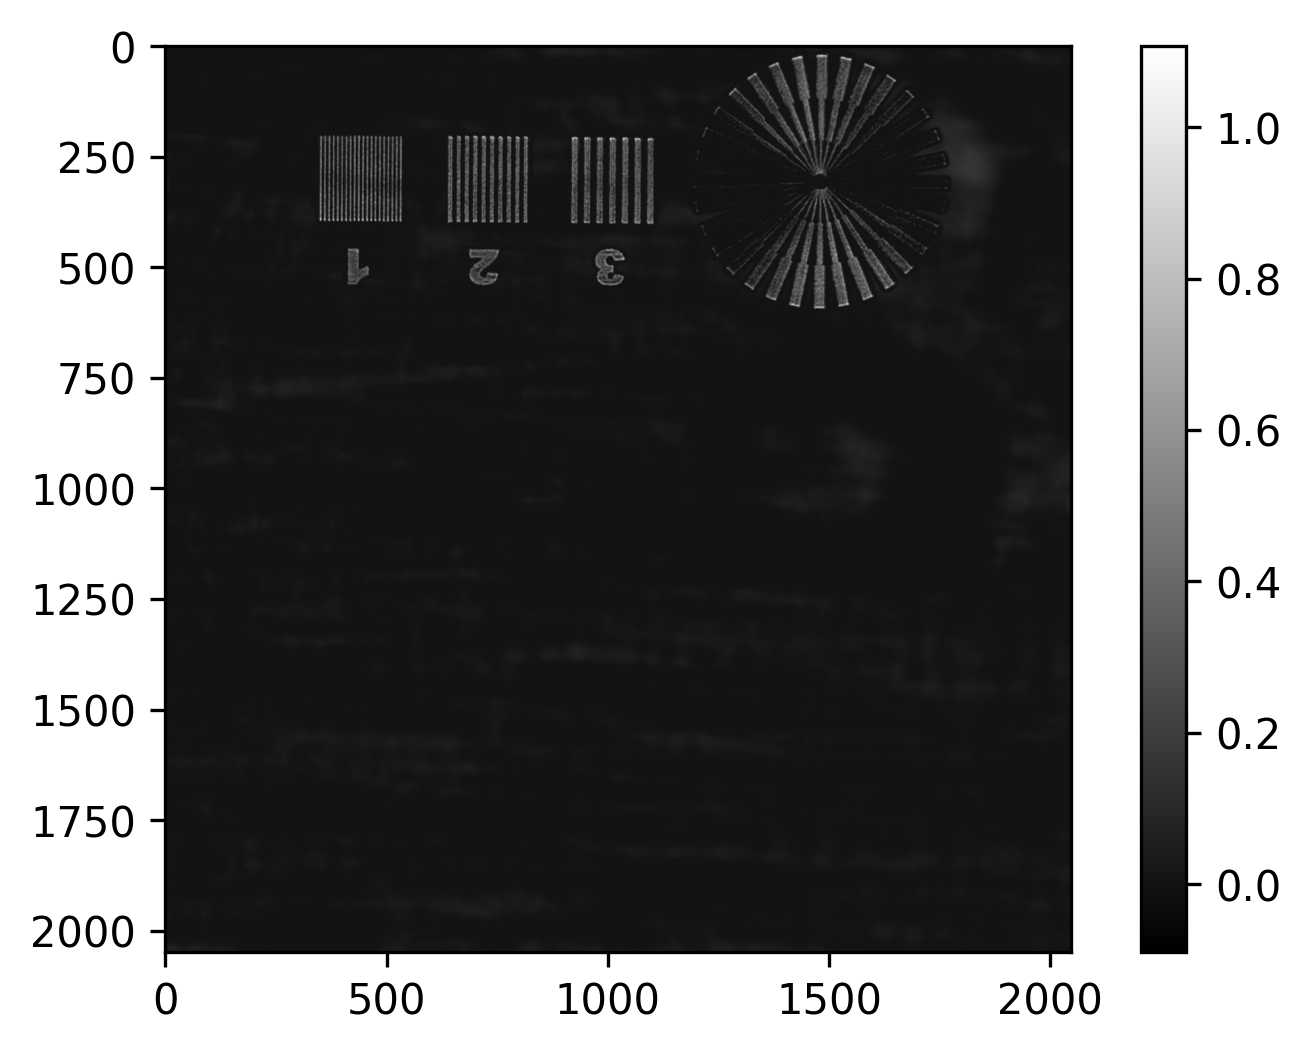

In [74]:
plt.figure(dpi=300)
plt.imshow(stokes_denoised[32,0],'gray')
plt.colorbar()

In [73]:
params = []

for i in range(len(qlipp.config.preproc_denoise_channels)):
    threshold = 2 #if qlipp.config.preproc_denoise_thresholds is None \
        #else qlipp.config.preproc_denoise_thresholds[i]
    level = 1 if qlipp.config.preproc_denoise_levels is None \
        else qlipp.config.preproc_denoise_levels[i]

    params.append([qlipp.config.preproc_denoise_channels[i], threshold, level])

stokes_denoised = np.copy(stokes)
for chan in range(len(params)):

    if 'S0' in params[chan][0]:
        for z in range(len(stokes)):
            stokes_denoised[z, 0, :, :] = wavelet_softThreshold(stokes[z, 0, :, :], 'db8',
                                                                params[chan][1], params[chan][2])
    elif 'S1' in params[chan][0]:
        for z in range(len(stokes)):
            stokes_denoised[z, 1, :, :] = wavelet_softThreshold(stokes[z, 1, :, :], 'db8',
                                                                params[chan][1], params[chan][2])
    if 'S2' in params[chan][0]:
        for z in range(len(stokes)):
            stokes_denoised[z, 2, :, :] = wavelet_softThreshold(stokes[z, 2, :, :], 'db8',
                                                                params[chan][1], params[chan][2])

    if 'S3' in params[chan][0]:
        for z in range(len(stokes)):
            stokes_denoised[z, 3, :, :] = wavelet_softThreshold(stokes[z, 3, :, :], 'db8',
                                                                params[chan][1], params[chan][2])